**Auto Encoder Model**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
import glob
import os
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
class CelebADataset(torch.utils.data.Dataset):
    def __init__(self, path, transform=None):
        self.image_paths = glob.glob(os.path.join(path, "*.jpg"))
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

In [7]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

In [15]:
data_path = "/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba"

dataset = CelebADataset(data_path, transform=transform)
loader = DataLoader(dataset, batch_size=512, shuffle=True, num_workers=4,pin_memory=True)

In [6]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),   # 64 → 32
            nn.ReLU(True),
            
            nn.Conv2d(32, 64, 4, 2, 1),  # 32 → 16
            nn.ReLU(True),
            
            nn.Conv2d(64, 128, 4, 2, 1), # 16 → 8
            nn.ReLU(True),
            
            nn.Conv2d(128, 256, 4, 2, 1), # 8 → 4
            nn.ReLU(True)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), # 4 → 8
            nn.ReLU(True),
            
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 8 → 16
            nn.ReLU(True),
            
            nn.ConvTranspose2d(64, 32, 4, 2, 1),   # 16 → 32
            nn.ReLU(True),
            
            nn.ConvTranspose2d(32, 3, 4, 2, 1),    # 32 → 64
            nn.Sigmoid()
        )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [7]:
model = AutoEncoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [8]:
epochs = 10
outputs = []
for epoch in range(epochs):
    total_loss = 0
    
    for image in loader:
        image = image.to(device)
        
        recon = model(image)
        loss = criterion(recon, image)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(loader):.4f}")
    outputs.append((epoch, image, recon))

Epoch [1/10], Loss: 0.0193
Epoch [2/10], Loss: 0.0060
Epoch [3/10], Loss: 0.0047
Epoch [4/10], Loss: 0.0041
Epoch [5/10], Loss: 0.0036
Epoch [6/10], Loss: 0.0030
Epoch [7/10], Loss: 0.0027
Epoch [8/10], Loss: 0.0026
Epoch [9/10], Loss: 0.0024
Epoch [10/10], Loss: 0.0023


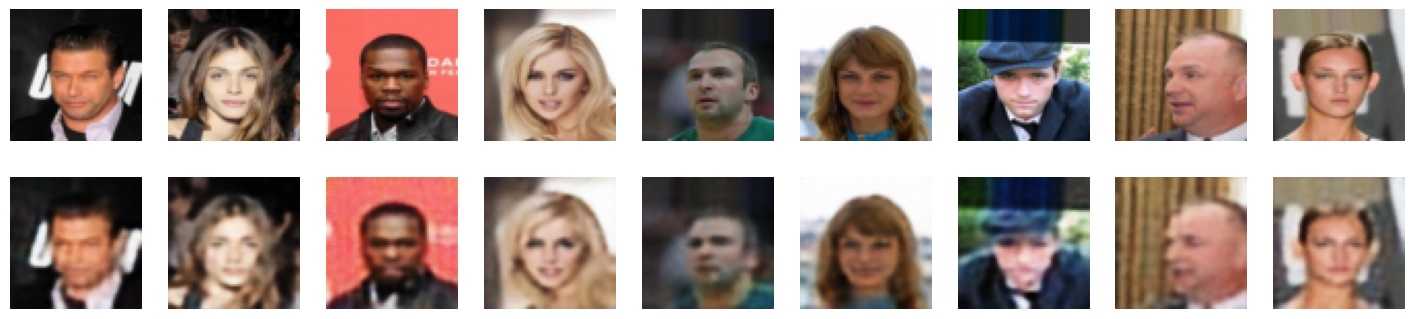

In [11]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    images = next(iter(loader))
    images = images.to(device)
    recon = model(images)

images = images.cpu()
recon = recon.cpu()

plt.figure(figsize=(18, 4))

for i in range(9):
    # Original
    plt.subplot(2, 9, i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.axis("off")
    
    # Reconstruction
    plt.subplot(2, 9, 9+i+1)
    plt.imshow(recon[i].permute(1,2,0))
    plt.axis("off")

plt.show()


**Variational Autoencoder**

In [24]:
class VAE(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),   # 64 → 32
            nn.ReLU(True),
            
            nn.Conv2d(32, 64, 4, 2, 1),  # 32 → 16
            nn.ReLU(True),
            
            nn.Conv2d(64, 128, 4, 2, 1), # 16 → 8
            nn.ReLU(True),
            
            nn.Conv2d(128, 256, 4, 2, 1), # 8 → 4
            nn.ReLU(True)
        )
        
        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(256*4*4, latent_dim)
        self.fc_logvar = nn.Linear(256*4*4, latent_dim)
        
        self.fc_decode = nn.Linear(latent_dim, 256*4*4)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Sigmoid()
        )
        
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.flatten(x)
        
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        
        z = self.reparameterize(mu, logvar)
        
        x = self.fc_decode(z)
        x = x.view(-1, 256, 4, 4)
        x = self.decoder(x)
        
        return x, mu, logvar


In [26]:
model = VAE(latent_dim=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
lossfn = nn.BCELoss(reduction = "sum")

In [27]:
epochs = 30
outputs = []
for epoch in range(epochs):
    total_loss = 0
    total_recon = 0
    total_kl = 0
    
    for image in loader:
        image = image.to(device)
        
        recon, mu, logvar = model(image)
        
        recon_loss = lossfn(recon,image)
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + kl_loss
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_recon += recon_loss.item() / image.size(0)
        total_kl += kl_loss.item() / image.size(0)
    
    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Total: {total_loss/len(loader):.4f}")
    print(f"Recon: {total_recon/len(loader):.4f}")
    print(f"KL: {total_kl/len(loader):.4f}")
    outputs.append((epoch, image, recon))

Epoch [1/30]
Total: 3525667.7323
Recon: 6819.2065
KL: 71.7851
Epoch [2/30]
Total: 3286276.0556
Recon: 6334.2714
KL: 89.0289
Epoch [3/30]
Total: 3249702.1900
Recon: 6260.9781
KL: 90.9117
Epoch [4/30]
Total: 3234827.6907
Recon: 6227.1897
KL: 95.5907
Epoch [5/30]
Total: 3226131.0997
Recon: 6206.2075
KL: 99.5815
Epoch [6/30]
Total: 3220307.9710
Recon: 6192.2471
KL: 102.2168
Epoch [7/30]
Total: 3216299.7330
Recon: 6182.8779
KL: 103.6652
Epoch [8/30]
Total: 3212872.8725
Recon: 6174.8364
KL: 104.9883
Epoch [9/30]
Total: 3210045.7696
Recon: 6167.7443
KL: 106.6037
Epoch [10/30]
Total: 3207486.7247
Recon: 6161.3735
KL: 108.0317
Epoch [11/30]
Total: 3205442.8832
Recon: 6155.7685
KL: 109.5525
Epoch [12/30]
Total: 3203857.9855
Recon: 6151.4009
KL: 110.8901
Epoch [13/30]
Total: 3201592.2323
Recon: 6145.9034
KL: 111.9289
Epoch [14/30]
Total: 3200465.9249
Recon: 6142.8402
KL: 112.7706
Epoch [15/30]
Total: 3199788.3984
Recon: 6140.8497
KL: 113.4744
Epoch [16/30]
Total: 3198789.0025
Recon: 6138.2738
KL:

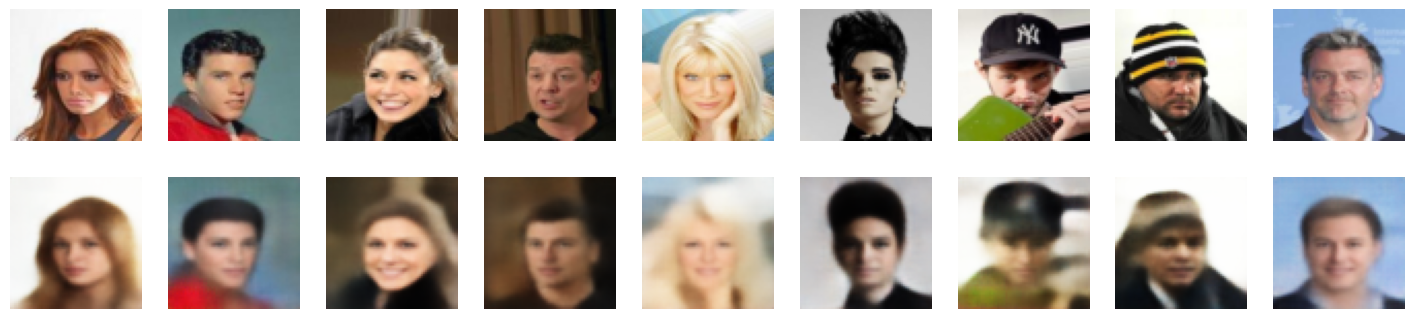

In [28]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    images = next(iter(loader))
    images = images.to(device)
    recon, _, _ = model(images)

images = images.cpu()
recon = recon.cpu()

plt.figure(figsize=(18, 4))

for i in range(9):
    # Original
    plt.subplot(2, 9, i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.axis("off")
    
    # Reconstruction
    plt.subplot(2, 9, 9+i+1)
    plt.imshow(recon[i].permute(1,2,0))
    plt.axis("off")

plt.show()


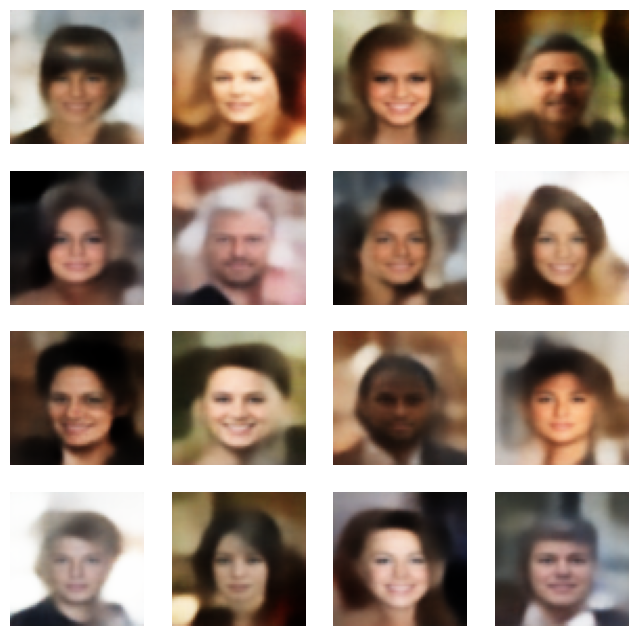

In [29]:
model.eval()
with torch.no_grad():
    z = torch.randn(16,128).to(device)
    samples = model.decoder(
        model.fc_decode(z).view(-1, 256, 4, 4)
    ).cpu()

plt.figure(figsize=(8,8))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(samples[i].permute(1,2,0))
    plt.axis("off")
plt.show()


**GANs**

In [20]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [21]:
data_path = "/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba"

dataset = CelebADataset(data_path, transform=transform)
loader = DataLoader(dataset, batch_size=256, shuffle=True, num_workers=4,pin_memory=True)

In [31]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


In [32]:
class Generator(nn.Module):
    def __init__(self, z_dim=100, ngf=64):
        super().__init__()

        self.main = nn.Sequential(
            # input Z: (batch, z_dim, 1, 1)
            nn.ConvTranspose2d(z_dim, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(True),

            # 4x4
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),

            # 8x8
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),

            # 16x16
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            # 32x32
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh()
            # 64x64
        )

    def forward(self, z):
        return self.main(z)


In [33]:
class Discriminator(nn.Module):
    def __init__(self, ndf=64):
        super().__init__()

        self.main = nn.Sequential(
            # 64x64
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # 32x32
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2),
            nn.LeakyReLU(0.2, inplace=True),

            # 16x16
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4),
            nn.LeakyReLU(0.2, inplace=True),

            # 8x8
            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*8),
            nn.LeakyReLU(0.2, inplace=True),

            # 4x4
            nn.Conv2d(ndf*8, 1, 4, 1, 0, bias=False)
        )

    def forward(self, x):
        return self.main(x).view(-1, 1)


In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

z_dim = 100

G = Generator(z_dim).to(device)
D = Discriminator().to(device)

G.apply(weights_init)
D.apply(weights_init)

criterion = nn.BCEWithLogitsLoss()

optimizer_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))


In [35]:
num_epochs = 50

for epoch in range(num_epochs):
    for real_images in loader:

        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # -------------------
        # Train Discriminator
        # -------------------

        z = torch.randn(batch_size, z_dim, 1, 1, device=device)
        fake_images = G(z)

        real_loss = criterion(D(real_images), real_labels)
        fake_loss = criterion(D(fake_images.detach()), fake_labels)

        d_loss = real_loss + fake_loss

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # -------------------
        # Train Generator
        # -------------------

        z = torch.randn(batch_size, z_dim, 1, 1, device=device)
        fake_images = G(z)

        g_loss = criterion(D(fake_images), real_labels)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"D Loss: {d_loss.item():.4f} "
          f"G Loss: {g_loss.item():.4f}")


Epoch [1/50] D Loss: 0.4788 G Loss: 3.2708
Epoch [2/50] D Loss: 0.4450 G Loss: 3.2939
Epoch [3/50] D Loss: 0.6806 G Loss: 2.9082
Epoch [4/50] D Loss: 0.7167 G Loss: 0.3925
Epoch [5/50] D Loss: 1.0064 G Loss: 2.8889
Epoch [6/50] D Loss: 0.5200 G Loss: 2.8751
Epoch [7/50] D Loss: 1.1627 G Loss: 1.6001
Epoch [8/50] D Loss: 0.5881 G Loss: 0.9712
Epoch [9/50] D Loss: 0.5380 G Loss: 1.7763
Epoch [10/50] D Loss: 0.5633 G Loss: 3.0143
Epoch [11/50] D Loss: 0.9706 G Loss: 0.9428
Epoch [12/50] D Loss: 2.1869 G Loss: 3.5178
Epoch [13/50] D Loss: 0.7923 G Loss: 3.0268
Epoch [14/50] D Loss: 0.5241 G Loss: 3.0693
Epoch [15/50] D Loss: 0.6068 G Loss: 1.0018
Epoch [16/50] D Loss: 0.5584 G Loss: 3.3761
Epoch [17/50] D Loss: 0.5087 G Loss: 3.2622
Epoch [18/50] D Loss: 0.3203 G Loss: 3.0565
Epoch [19/50] D Loss: 0.7090 G Loss: 4.6968
Epoch [20/50] D Loss: 0.5095 G Loss: 2.7412
Epoch [21/50] D Loss: 0.7117 G Loss: 1.3041
Epoch [22/50] D Loss: 0.6369 G Loss: 2.6659
Epoch [23/50] D Loss: 0.2175 G Loss: 3.09

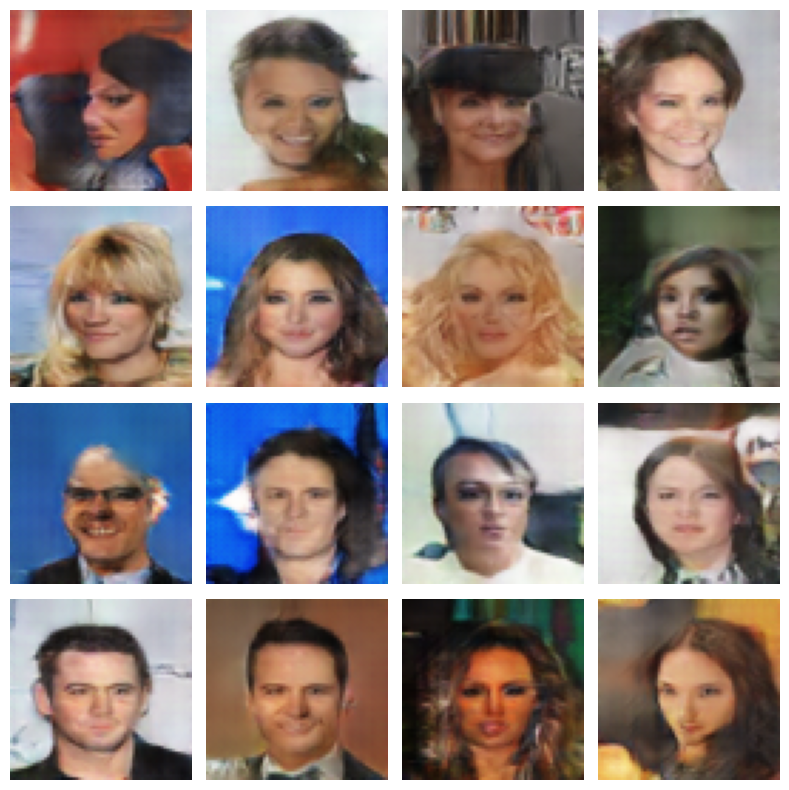

In [36]:
import matplotlib.pyplot as plt

G.eval()

with torch.no_grad():
    z = torch.randn(16, 100, 1, 1, device=device)
    fake_images = G(z)

# Convert from [-1,1] → [0,1]
fake_images = (fake_images + 1) / 2
fake_images = fake_images.clamp(0, 1)

plt.figure(figsize=(8,8))

for i in range(16):
    plt.subplot(4, 4, i+1)
    img = fake_images[i].cpu().permute(1, 2, 0)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()


WGAN

In [4]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [5]:
data_path = "/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba"

dataset = CelebADataset(data_path, transform=transform)
loader = DataLoader(dataset, batch_size=256, shuffle=True, num_workers=4,pin_memory=True)

In [6]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)
    elif classname.find("InstanceNorm") != -1:
        if m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0)

In [7]:
class Generator(nn.Module):
    def __init__(self, z_dim=100, ngf=64):
        super().__init__()

        self.main = nn.Sequential(
            # input Z: (batch, z_dim, 1, 1)
            nn.ConvTranspose2d(z_dim, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(True),

            # 4x4
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),

            # 8x8
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),

            # 16x16
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            # 32x32
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh()
            # 64x64
        )

    def forward(self, z):
        return self.main(z)


In [8]:
class Critic(nn.Module):
    def __init__(self, channels_img=3, features_d=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels_img, features_d, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            self._block(features_d, features_d * 2, 4, 2, 1),
            self._block(features_d * 2, features_d * 4, 4, 2, 1),
            self._block(features_d * 4, features_d * 8, 4, 2, 1),

            nn.Conv2d(features_d * 8, 1, kernel_size=4, stride=1, padding=0)
        )

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.InstanceNorm2d(out_channels, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
        )

    def forward(self, x):
        return self.net(x)

In [11]:
def gradient_penalty(critic, real, fake, device):
    batch_size, c, h, w = real.shape
    epsilon = torch.rand(batch_size, 1, 1, 1, device=device).repeat(1, c, h, w)
    interpolated_images = real * epsilon + fake * (1 - epsilon)
    interpolated_images.requires_grad_(True)

    mixed_scores = critic(interpolated_images)

    gradient = torch.autograd.grad(
        inputs=interpolated_images,
        outputs=mixed_scores,
        grad_outputs=torch.ones_like(mixed_scores),
        create_graph=True,
        retain_graph=True,
    )[0]

    gradient = gradient.view(gradient.size(0), -1)
    gradient_norm = gradient.norm(2, dim=1)
    gp = torch.mean((gradient_norm - 1) ** 2)
    return gp

In [12]:
# ----------------------------
# Hyperparameters
# ----------------------------
latent_dim = 100
lr = 2e-4
betas = (0.0, 0.9)
lambda_gp = 10
n_critic = 5
epochs = 30

# ----------------------------
# Initialize models
# ----------------------------
gen = Generator(z_dim=latent_dim, ngf=64).to(device)
critic = Critic(channels_img=3, features_d=64).to(device)

gen.apply(weights_init)
critic.apply(weights_init)

# ----------------------------
# Optimizers
# ----------------------------
opt_gen = torch.optim.Adam(gen.parameters(), lr=lr, betas=betas)
opt_critic = torch.optim.Adam(critic.parameters(), lr=lr, betas=betas)

# Fixed noise for visualization
fixed_noise = torch.randn(16, latent_dim, 1, 1, device=device)

# For storing progress
gen_losses = []
critic_losses = []
sample_outputs = []

# ----------------------------
# Training loop
# ----------------------------
for epoch in range(epochs):
    epoch_gen_loss = 0.0
    epoch_critic_loss = 0.0
    num_batches = 0

    for batch in loader:
        # If dataloader returns (images, labels), take only images
        if isinstance(batch, (list, tuple)):
            real = batch[0]
        else:
            real = batch

        real = real.to(device)
        cur_batch_size = real.size(0)

        # ----------------------------
        # Train Critic
        # ----------------------------
        for _ in range(n_critic):
            noise = torch.randn(cur_batch_size, latent_dim, 1, 1, device=device)
            fake = gen(noise)

            critic_real = critic(real).reshape(-1)
            critic_fake = critic(fake.detach()).reshape(-1)

            gp = gradient_penalty(critic, real, fake.detach(), device=device)

            loss_critic = -(torch.mean(critic_real) - torch.mean(critic_fake)) + lambda_gp * gp

            opt_critic.zero_grad()
            loss_critic.backward()
            opt_critic.step()

        # ----------------------------
        # Train Generator
        # ----------------------------
        noise = torch.randn(cur_batch_size, latent_dim, 1, 1, device=device)
        fake = gen(noise)
        gen_fake = critic(fake).reshape(-1)

        loss_gen = -torch.mean(gen_fake)

        opt_gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()

        epoch_gen_loss += loss_gen.item()
        epoch_critic_loss += loss_critic.item()
        num_batches += 1

    avg_gen_loss = epoch_gen_loss / num_batches
    avg_critic_loss = epoch_critic_loss / num_batches

    gen_losses.append(avg_gen_loss)
    critic_losses.append(avg_critic_loss)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Critic Loss: {avg_critic_loss:.4f}")
    print(f"Generator Loss: {avg_gen_loss:.4f}")

    # ----------------------------
    # Save sample outputs
    # ----------------------------
    with torch.no_grad():
        fake_samples = gen(fixed_noise).detach().cpu()

    sample_outputs.append((epoch + 1, fake_samples))

Epoch [1/30]
Critic Loss: -19.0111
Generator Loss: 63.7447
Epoch [2/30]
Critic Loss: -12.8164
Generator Loss: 84.5124
Epoch [3/30]
Critic Loss: -10.8306
Generator Loss: 90.7408
Epoch [4/30]
Critic Loss: -9.7722
Generator Loss: 95.8775
Epoch [5/30]
Critic Loss: -9.0986
Generator Loss: 100.4136
Epoch [6/30]
Critic Loss: -8.6507
Generator Loss: 102.8123
Epoch [7/30]
Critic Loss: -8.2766
Generator Loss: 102.1434
Epoch [8/30]
Critic Loss: -8.0076
Generator Loss: 100.7325
Epoch [9/30]
Critic Loss: -7.7600
Generator Loss: 98.3282
Epoch [10/30]
Critic Loss: -7.5259
Generator Loss: 95.9034
Epoch [11/30]
Critic Loss: -7.2632
Generator Loss: 91.2867
Epoch [12/30]
Critic Loss: -7.1280
Generator Loss: 87.5555
Epoch [13/30]
Critic Loss: -6.8980
Generator Loss: 81.7846
Epoch [14/30]
Critic Loss: -6.7695
Generator Loss: 76.7130
Epoch [15/30]
Critic Loss: -6.5324
Generator Loss: 69.2293
Epoch [16/30]
Critic Loss: -6.3865
Generator Loss: 62.7532
Epoch [17/30]
Critic Loss: -6.3311
Generator Loss: 56.2790

In [19]:
def generate_random_faces(gen, latent_dim, num_samples=16, device="cuda"):
    gen.eval()  # set to eval mode

    with torch.no_grad():
        noise = torch.randn(num_samples, latent_dim, 1, 1, device=device)
        fake_images = gen(noise).cpu()

    # Convert from [-1, 1] → [0, 1]
    fake_images = (fake_images + 1) / 2
    fake_images = torch.clamp(fake_images, 0, 1)

    grid = torchvision.utils.make_grid(fake_images, nrow=4, padding=2)

    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title("Randomly Generated Faces")
    plt.axis("off")
    plt.show()

In [30]:
def generate_and_check(gen, latent_dim, device, num_samples=16):
    gen.eval()
    with torch.no_grad():
        z = torch.randn(num_samples, latent_dim, 1, 1, device=device)
        imgs = gen(z).cpu()

    # numerical diversity check
    for i in range(1, min(8, num_samples)):
        diff = torch.mean(torch.abs(imgs[0] - imgs[i])).item()
        print(f"Diff(img0, img{i}) = {diff:.6f}")

    # show images
    imgs = (imgs + 1) / 2
    imgs = torch.clamp(imgs, 0, 1)

    grid = torchvision.utils.make_grid(imgs, nrow=4, padding=2)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.title("Generated Random Faces")
    plt.show()

In [34]:
torch.save(gen.state_dict(), "generator_epoch30.pth")
torch.save(critic.state_dict(), "critic_epoch30.pth")

Diff(img0, img1) = 0.520247
Diff(img0, img2) = 0.460012
Diff(img0, img3) = 0.568854
Diff(img0, img4) = 0.695869
Diff(img0, img5) = 0.427132
Diff(img0, img6) = 0.657977
Diff(img0, img7) = 0.755318


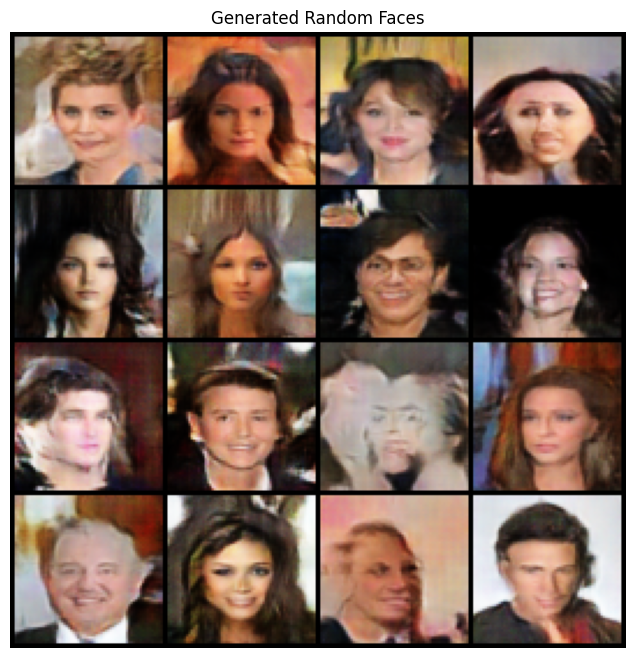

In [46]:
generate_and_check(gen, latent_dim, device)

Diffusion

In [1]:
!pip install diffusers accelerate

In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import glob
import os

class CelebADataset(Dataset):
    def __init__(self, path, transform=None):
        self.image_paths = glob.glob(os.path.join(path, "*.jpg"))
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

data_path = "/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba"
dataset = CelebADataset(data_path, transform=transform)
loader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)

In [4]:
import torch
import torch.nn.functional as F
from diffusers import UNet2DModel, DDPMScheduler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet2DModel(
    sample_size=64,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 256, 256),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
).to(device)

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [5]:
from tqdm import tqdm

epochs = 20

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for images in tqdm(loader):
        images = images.to(device)
        noise = torch.randn_like(images)

        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (images.size(0),),
            device=device
        ).long()

        noisy_images = noise_scheduler.add_noise(images, noise, timesteps)

        noise_pred = model(noisy_images, timesteps).sample
        loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {total_loss/len(loader):.4f}")
    torch.save(model.state_dict(), "ddpm_celeba64.pth")


100%|██████████| 1583/1583 [26:52<00:00,  1.02s/it]


Epoch [1/20] Loss: 0.0409


100%|██████████| 1583/1583 [26:51<00:00,  1.02s/it]


Epoch [2/20] Loss: 0.0211


100%|██████████| 1583/1583 [26:51<00:00,  1.02s/it]


...

Epoch [18/20] Loss: 0.0171


100%|██████████| 1583/1583 [26:50<00:00,  1.02s/it]


Epoch [19/20] Loss: 0.0169


100%|██████████| 1583/1583 [26:50<00:00,  1.02s/it]


Epoch [20/20] Loss: 0.0169


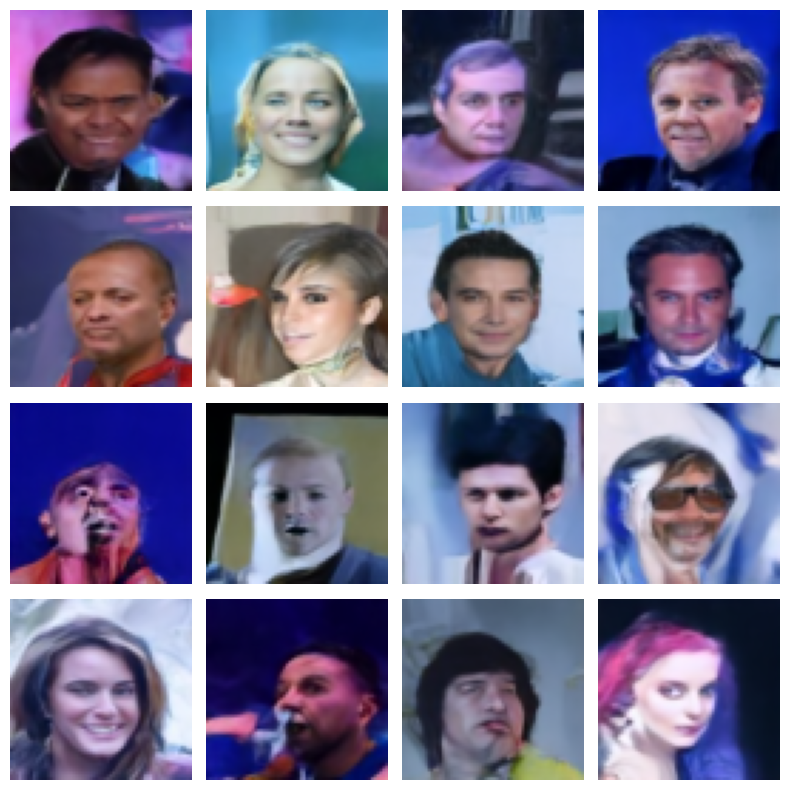

In [8]:
import matplotlib.pyplot as plt

model.eval()

num_samples = 16
sample = torch.randn(num_samples, 3, 64, 64).to(device)

scheduler = DDPMScheduler(num_train_timesteps=1000)

for t in scheduler.timesteps:
    with torch.no_grad():
        residual = model(sample, t).sample
    sample = scheduler.step(residual, t, sample).prev_sample

images = (sample.clamp(-1, 1) + 1) / 2
images = images.cpu()

plt.figure(figsize=(8, 8))
for i in range(num_samples):
    plt.subplot(4, 4, i + 1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.axis("off")
plt.tight_layout()
plt.show()